In [1]:
# setting root at top

import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))

# Base Model with 64x64 Image and 4 Conv Blocks
# Using 0.001 learning rate

### Import libraries
* `torch`
* `datasets`, `transforms` from `torchvision` for data Loading.
* `DataLoader` from `torch.utils.data` for Batching and using data in model.
* `BaseModel` from `architectures.BaseModel.py`
* `matplotlib.pyplot` as `plt`
* `seaborn` as sns
* `trainer` from `modules.TrainTest`

In [2]:
# training and architecture
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from architectures.BaseModel import BaseModel

# visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#trainer and tester modules
from modules.TrainTest import trainer

### Load datasets for training
* load 64x64 images
* load from `../dataset/final-dataset/train`
* convert to tensor
* make batch_size = 32

In [3]:
train_transform = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor()
    ]
)

train_dataset = datasets.ImageFolder(
    root="../dataset/final-dataset/train",
    transform=train_transform
)

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

### Load datasets for training
* load 64x64 images
* load from `../dataset/final-dataset/train`
* convert to tensor
* make batch_size = 32

In [4]:
valid_transform = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor()
    ]
)

valid_dataset = datasets.ImageFolder(
    root="../dataset/final-dataset/valid",
    transform=valid_transform
)

valid_dataloader = DataLoader(
    dataset=valid_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

### Use Model for training
Initialize model using 
* `conv_layers = 4`, 
* `initial_output_channel = 8` 
* `initial_image_size = 64`

In [5]:
model = BaseModel(conv_layers=4, initial_output_channel=8, initial_image_size=64).to("cuda")

In [6]:
metrics = trainer(
    model=model,
    train_dataloader=train_dataloader,
    test_dataloader=valid_dataloader,
    epoch=50,
    lr=0.001,
    print_on=5,
    save_dir="../models/base_64x64_4conv/",
    save_checkpoints=15,
    checkpoint_name="base_64x64_train_0_"
)

Epoch 5/50 | Train Loss: 0.8720 | Validation Loss: 0.8717
Epoch 10/50 | Train Loss: 0.8714 | Validation Loss: 0.8702
Epoch 15/50 | Train Loss: 0.8681 | Validation Loss: 0.8686
Epoch 20/50 | Train Loss: 0.8677 | Validation Loss: 0.8658
Epoch 25/50 | Train Loss: 0.8635 | Validation Loss: 0.8631
Epoch 30/50 | Train Loss: 0.8599 | Validation Loss: 0.8589
Epoch 35/50 | Train Loss: 0.8554 | Validation Loss: 0.8546
Epoch 40/50 | Train Loss: 0.8496 | Validation Loss: 0.8478
Epoch 45/50 | Train Loss: 0.8414 | Validation Loss: 0.8418
Epoch 50/50 | Train Loss: 0.8295 | Validation Loss: 0.8323


## Visualize

Convert metrics to a pd.DataFrame and add epoch column for visualization.

In [13]:
metrics = pd.DataFrame(metrics)
epochs = [i+1 for i  in range(len(metrics))]
metrics["epoch"] = epochs

In [14]:
metrics.head(10)

,epoch,training_loss,training_accuracy,training_precision,training_recall,training_f1,test_loss,test_accuracy,test_precision,test_recall,test_f1
0,1,1.056406,0.492987,0.282474,0.333102,0.246360,1.009529,0.521389,0.173796,0.333333,0.228471
1,2,0.956829,0.521949,0.173983,0.333333,0.228632,0.907010,0.521389,0.173796,0.333333,0.228471
2,3,0.886108,0.521949,0.173983,0.333333,0.228632,0.874891,0.521389,0.173796,0.333333,0.228471
3,4,0.873022,0.521949,0.173983,0.333333,0.228632,0.872938,0.521389,0.173796,0.333333,0.228471
4,5,0.871964,0.521949,0.173983,0.333333,0.228632,0.871663,0.521389,0.173796,0.333333,0.228471
5,6,0.871854,0.521949,0.173983,0.333333,0.228632,0.871292,0.521389,0.173796,0.333333,0.228471
6,7,0.871123,0.521949,0.173983,0.333333,0.228632,0.871519,0.521389,0.173796,0.333333,0.228471
7,8,0.870881,0.521949,0.173983,0.333333,0.228632,0.871261,0.521389,0.173796,0.333333,0.228471
8,9,0.871775,0.521949,0.173983,0.333333,0.228632,0.870525,0.521389,0.173796,0.333333,0.228471
9,10,0.871389,0.521949,0.173983,0.333333,0.228632,0.870166,0.521389,0.173796,0.333333,0.228471


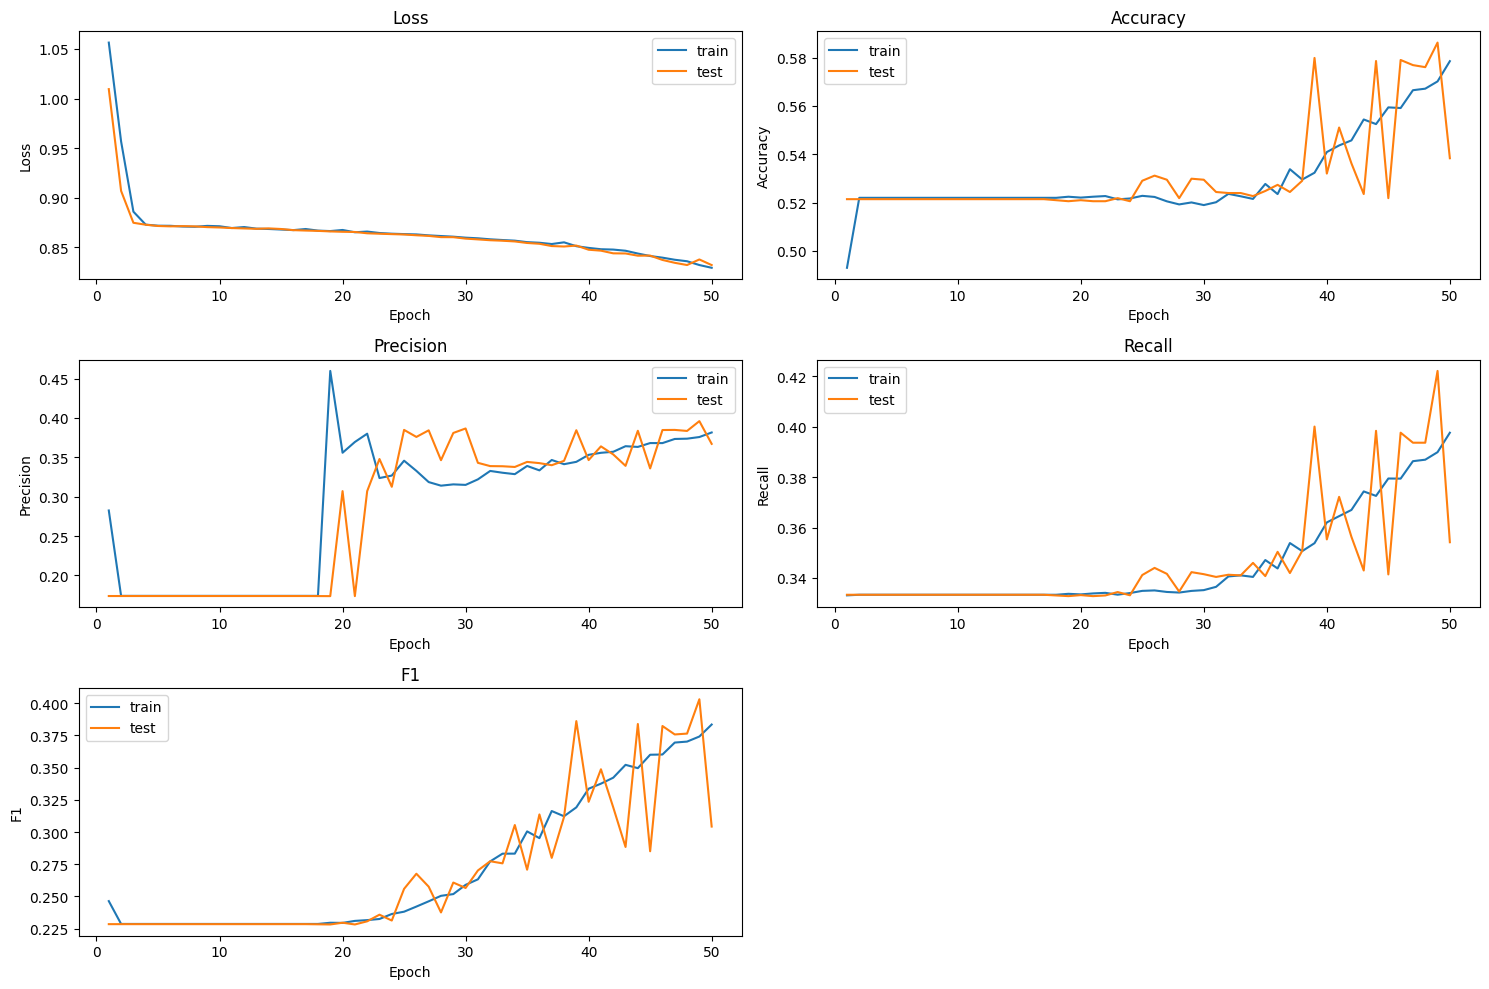

In [15]:
fig, axes = plt.subplots(3, 2, figsize=(15, 10))
axes = axes.flatten()

to_viz = [
    "loss",
    "accuracy",
    "precision",
    "recall",
    "f1"
]

for i, metric in enumerate(to_viz):

    ax = axes[i]

    sns.lineplot(
        data=metrics,
        x="epoch",
        y=f"training_{metric}",
        ax=ax,
        label="train"
    )

    sns.lineplot(
        data=metrics,
        x="epoch",
        y=f"test_{metric}",
        ax=ax,
        label="test"
    )

    ax.set_title(metric.capitalize())
    ax.set_xlabel("Epoch")
    ax.set_ylabel(metric.capitalize())

# Hide unused subplot (6th slot)
axes[-1].axis("off")

plt.tight_layout()
plt.show()